In [210]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd

In [211]:
dataArray = pd.read_excel("practica2.xlsx", sheet_name="pyin1", header = None, decimal = ",").to_numpy()

In [212]:
largeDataArray = np.vstack((dataArray, np.flipud(dataArray[:-1,:])))
largerDataArray = np.hstack((largeDataArray, -np.fliplr(largeDataArray[:,:-1]) + 9.53*2))

In [213]:
xGrid = np.arange(0, largerDataArray.shape[0], step = 1)
yGrid = np.arange(0, largerDataArray.shape[1], step = 1)

In [214]:
interp = sp.interpolate.RegularGridInterpolator((xGrid, yGrid), largerDataArray)

In [215]:
xplot = np.linspace(xGrid.min(), xGrid.max(), 560)
yplot = np.linspace(yGrid.min(), yGrid.max(), 400)

X, Y = np.meshgrid(xplot, yplot, indexing='ij')
data = interp((X, Y))

In [216]:
fieldGradient = np.gradient(data)

In [217]:
normMatrix = np.sqrt(fieldGradient[0]**2 + fieldGradient[1]**2)
normalizedFieldGradientU = fieldGradient[0]/normMatrix
normalizedFieldGradientV = fieldGradient[1]/normMatrix

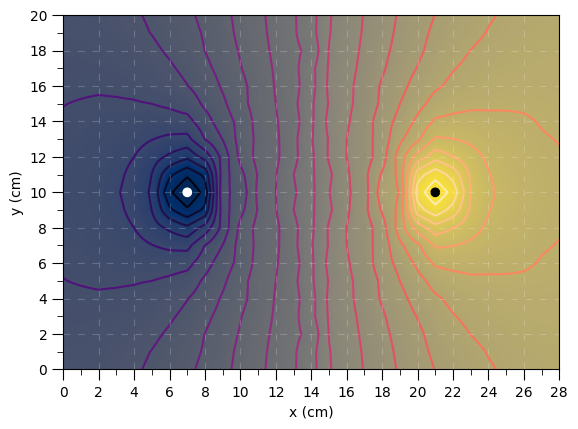

In [264]:
chargePositions = np.array([[7,10],[21,10]])
chargeColors = ["#FFFFFF","#000000"]

fig, ax = plt.subplots()

ax.imshow(data, aspect='equal', cmap = "cividis", origin = "lower", interpolation = "nearest", extent = [0,28,0,20])
ax.contour(Y, X, data, levels = 30, cmap = 'magma', zorder = 0)
ax.scatter(chargePositions[:,0], chargePositions[:,1], c = chargeColors)


ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#FFFFFF", zorder = 10, alpha = 0.2, ls = (0,(6,7)))

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")


plt.savefig("casoUnoEquipotencialesDipolo.png", dpi = 300)
plt.show()

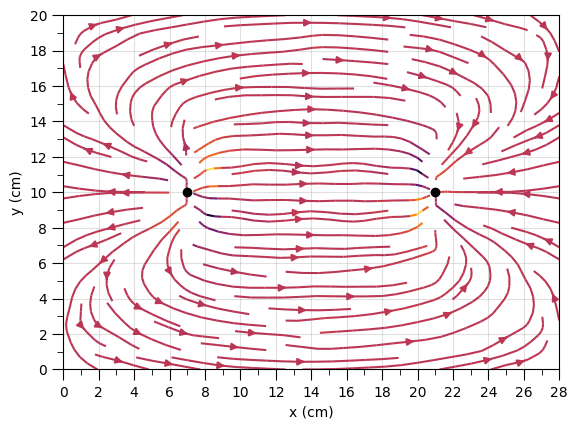

In [265]:
fig, ax = plt.subplots()

#skip = (slice(None, None, 20), slice(None, None, 20))
#ax.quiver(Y[skip],X[skip], normalizedFieldGradientV[skip], normalizedFieldGradientU[skip], fieldGradient[1][skip]*fieldGradient[0][skip], angles='xy', scale_units='xy', scale = 1, cmap = 'rainbow', pivot = "mid")
isStreamlineBroken = True
plt.streamplot(Y,X,fieldGradient[1], fieldGradient[0],
               color = fieldGradient[1]*fieldGradient[0],
               density = 1, cmap = "inferno",
               broken_streamlines = isStreamlineBroken,
               )
ax.scatter(chargePositions[:,0], chargePositions[:,1], c = "#000000", zorder = 10)

ax.set_xticks(np.arange(0, 29, 2))
ax.set_xticks(np.arange(1, 29, 2), minor=True)

ax.tick_params(axis='x', which='major', length=8)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_yticks(np.arange(0, 21, 2))
ax.set_yticks(np.arange(1, 21, 2), minor=True)

ax.tick_params(axis='y', which='major', length=8)
ax.tick_params(axis='y', which='minor', length=4)

ax.grid(color = "#666666", zorder = 10, alpha = 0.2, ls = "solid")

ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")

ax.set_aspect("equal")


plt.savefig(f"casoUnoCampoElectricoDipolo{isStreamlineBroken}.png", dpi = 300)
plt.show()

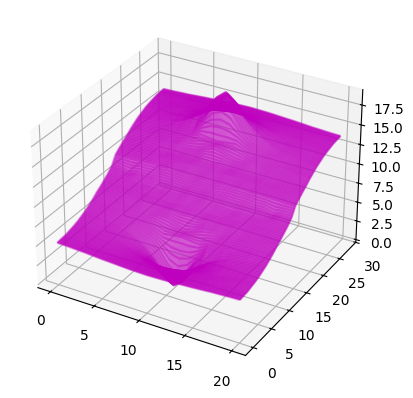

In [220]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot_wireframe(X, Y, interp((X, Y)), rstride=3, cstride=3,
                  alpha=0.4, color='m', label='linear interp')

plt.show()

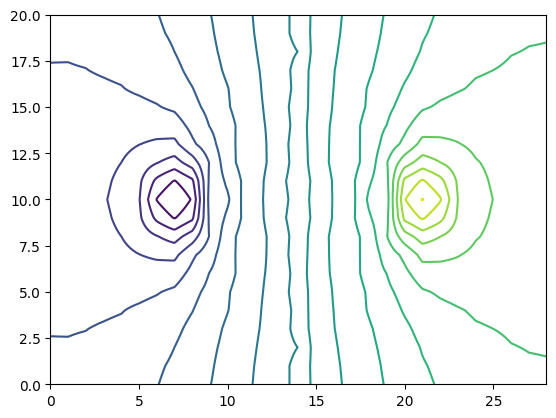

In [221]:
fig, ax = plt.subplots()

cp = ax.contour(Y, X, data, levels = 20, cmap = 'viridis')